# Day 15 — Phase 1 Review & Consolidation
### Week 1-2 Complete · Statistics · Probability · SQL · A/B Testing

## 1. Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import scipy

plt.style.use("dark_background")
sns.set_palette("husl")

df = pd.read_csv(r"C:\DS-AI-75d\titanic.csv")
con = duckdb.connect()
con.register("titanic", df)


def sql(query):
    return con.execute(query).df()


print(f"Pandas:  {pd.__version__}")
print(f"NumPy:   {np.__version__}")
print(f"SciPy:   {scipy.__version__}")
print(f"DuckDB:  {duckdb.__version__}")
print(f"Dataset: {df.shape}")
print("Phase 1 Review — Ready! ✅")

Pandas:  2.3.3
NumPy:   2.4.3
SciPy:   1.17.1
DuckDB:  1.5.1
Dataset: (891, 12)
Phase 1 Review — Ready! ✅


## 2. Statistics & Probability Review

In [ ]:
print("=" * 55)
print("     STATISTICS & PROBABILITY REVIEW")
print("=" * 55)

ages = df["Age"].dropna()
fares = df["Fare"]

# Descriptive Stats
print("\n📊 DESCRIPTIVE STATISTICS:")
print(f"  Age Mean:       {ages.mean():.2f}")
print(f"  Age Median:     {ages.median():.2f}")
print(f"  Age Std Dev:    {ages.std():.2f}")
print(f"  Age Skewness:   {stats.skew(ages):.2f}")
print(f"  Fare Mean:      {fares.mean():.2f}")
print(f"  Fare Skewness:  {stats.skew(fares):.2f}")

# Probability
print("\n🎲 PROBABILITY:")
p_survived = df["Survived"].mean()
p_female = (df["Sex"] == "female").mean()
p_surv_female = df[df["Sex"] == "female"]["Survived"].mean()
p_female_surv = (p_surv_female * p_female) / p_survived
print(f"  P(Survived):              {p_survived:.3f}")
print(f"  P(Female):                {p_female:.3f}")
print(f"  P(Survived|Female):       {p_surv_female:.3f}")
print(f"  P(Female|Survived):       {p_female_surv:.3f}  ← Bayes!")

# Distributions
print("\n📈 DISTRIBUTIONS:")
print(f"  Age ~ Normal(μ={ages.mean():.1f}, σ={ages.std():.1f})")
print(f"  68% of ages: {ages.mean()-ages.std():.1f} to {ages.mean()+ages.std():.1f}")
print(
    f"  95% of ages: {ages.mean()-2*ages.std():.1f} to {ages.mean()+2*ages.std():.1f}"
)

# Hypothesis Tests
print("\n🔬 HYPOTHESIS TESTS:")
surv_ages = df[df["Survived"] == 1]["Age"].dropna()
died_ages = df[df["Survived"] == 0]["Age"].dropna()
t, p = stats.ttest_ind(surv_ages, died_ages)
print(
    f"  Age vs Survival (t-test): p={p:.4f} → {'SIGNIFICANT ✅' if p<0.05 else 'NOT significant ❌'}"
)

ct = pd.crosstab(df["Sex"], df["Survived"])
chi2, p2, _, _ = stats.chi2_contingency(ct)
print(
    f"  Gender vs Survival (chi2): p={p2:.6f} → {'SIGNIFICANT ✅' if p2<0.05 else 'NOT significant ❌'}"
)

# Confidence Interval
se = stats.sem(ages)
ci = stats.t.interval(0.95, df=len(ages) - 1, loc=ages.mean(), scale=se)
print(f"\n📏 CONFIDENCE INTERVAL:")
print(f"  95% CI for mean age: ({ci[0]:.2f}, {ci[1]:.2f})")

     STATISTICS & PROBABILITY REVIEW

📊 DESCRIPTIVE STATISTICS:
  Age Mean:       29.70
  Age Median:     28.00
  Age Std Dev:    14.53
  Age Skewness:   0.39
  Fare Mean:      32.20
  Fare Skewness:  4.78

🎲 PROBABILITY:
  P(Survived):              0.384
  P(Female):                0.352
  P(Survived|Female):       0.742
  P(Female|Survived):       0.681  ← Bayes!

📈 DISTRIBUTIONS:
  Age ~ Normal(μ=29.7, σ=14.5)
  68% of ages: 15.2 to 44.2
  95% of ages: 0.6 to 58.8

🔬 HYPOTHESIS TESTS:
  Age vs Survival (t-test): p=0.0391 → SIGNIFICANT ✅
  Gender vs Survival (chi2): p=0.000000 → SIGNIFICANT ✅

📏 CONFIDENCE INTERVAL:
  95% CI for mean age: (28.63, 30.77)


## 3. SQL Review

In [ ]:
print("=" * 55)
print("            SQL REVIEW")
print("=" * 55)

# Fundamentals
print("\n📋 FUNDAMENTALS — Survival by class & gender:")
print(
    sql(
        """
    SELECT 
        Pclass,
        Sex,
        COUNT(*) as passengers,
        ROUND(AVG(Survived)*100, 1) as survival_pct,
        ROUND(AVG(Fare), 2) as avg_fare
    FROM titanic
    GROUP BY Pclass, Sex
    ORDER BY Pclass, Sex
"""
    )
)

# Window Functions
print("\n🪟 WINDOW FUNCTIONS — Top fare per class:")
print(
    sql(
        """
    SELECT Pclass, Name, Fare, Survived
    FROM (
        SELECT *,
            ROW_NUMBER() OVER (PARTITION BY Pclass ORDER BY Fare DESC) as rn
        FROM titanic
    )
    WHERE rn = 1
    ORDER BY Pclass
"""
    )
)

# CTE
print("\n📝 CTE — Above average fare survivors:")
print(
    sql(
        """
    WITH avg_fares AS (
        SELECT Pclass, AVG(Fare) as avg_fare
        FROM titanic
        GROUP BY Pclass
    ),
    above_avg AS (
        SELECT t.Pclass, t.Name, t.Fare, t.Survived
        FROM titanic t
        JOIN avg_fares a ON t.Pclass = a.Pclass
        WHERE t.Fare > a.avg_fare AND t.Survived = 1
    )
    SELECT Pclass,
           COUNT(*) as survivors,
           ROUND(AVG(Fare), 2) as avg_fare
    FROM above_avg
    GROUP BY Pclass
    ORDER BY Pclass
"""
    )
)

# Date/Business
print("\n📅 BUSINESS SQL — Embarked port analysis:")
print(
    sql(
        """
    SELECT 
        Embarked,
        COUNT(*) as passengers,
        ROUND(AVG(Survived)*100,1) as survival_pct,
        ROUND(AVG(Fare), 2) as avg_fare,
        CASE 
            WHEN AVG(Fare) > 50 THEN 'Premium port'
            WHEN AVG(Fare) > 25 THEN 'Mid-range port'
            ELSE 'Budget port'
        END as port_tier
    FROM titanic
    WHERE Embarked IS NOT NULL
    GROUP BY Embarked
    ORDER BY avg_fare DESC
"""
    )
)

            SQL REVIEW

📋 FUNDAMENTALS — Survival by class & gender:
   Pclass     Sex  passengers  survival_pct  avg_fare
0       1  female          94          96.8    106.13
1       1    male         122          36.9     67.23
2       2  female          76          92.1     21.97
3       2    male         108          15.7     19.74
4       3  female         144          50.0     16.12
5       3    male         347          13.5     12.66

🪟 WINDOW FUNCTIONS — Top fare per class:
   Pclass                        Name      Fare  Survived
0       1            Ward, Miss. Anna  512.3292         1
1       2        Hood, Mr. Ambrose Jr   73.5000         0
2       3  Sage, Master. Thomas Henry   69.5500         0

📝 CTE — Above average fare survivors:
   Pclass  survivors  avg_fare
0       1         51    167.13
1       2         45     30.13
2       3         41     23.81

📅 BUSINESS SQL — Embarked port analysis:
  Embarked  passengers  survival_pct  avg_fare       port_tier
0        C 

## 4. Phase 1 Visual Summary

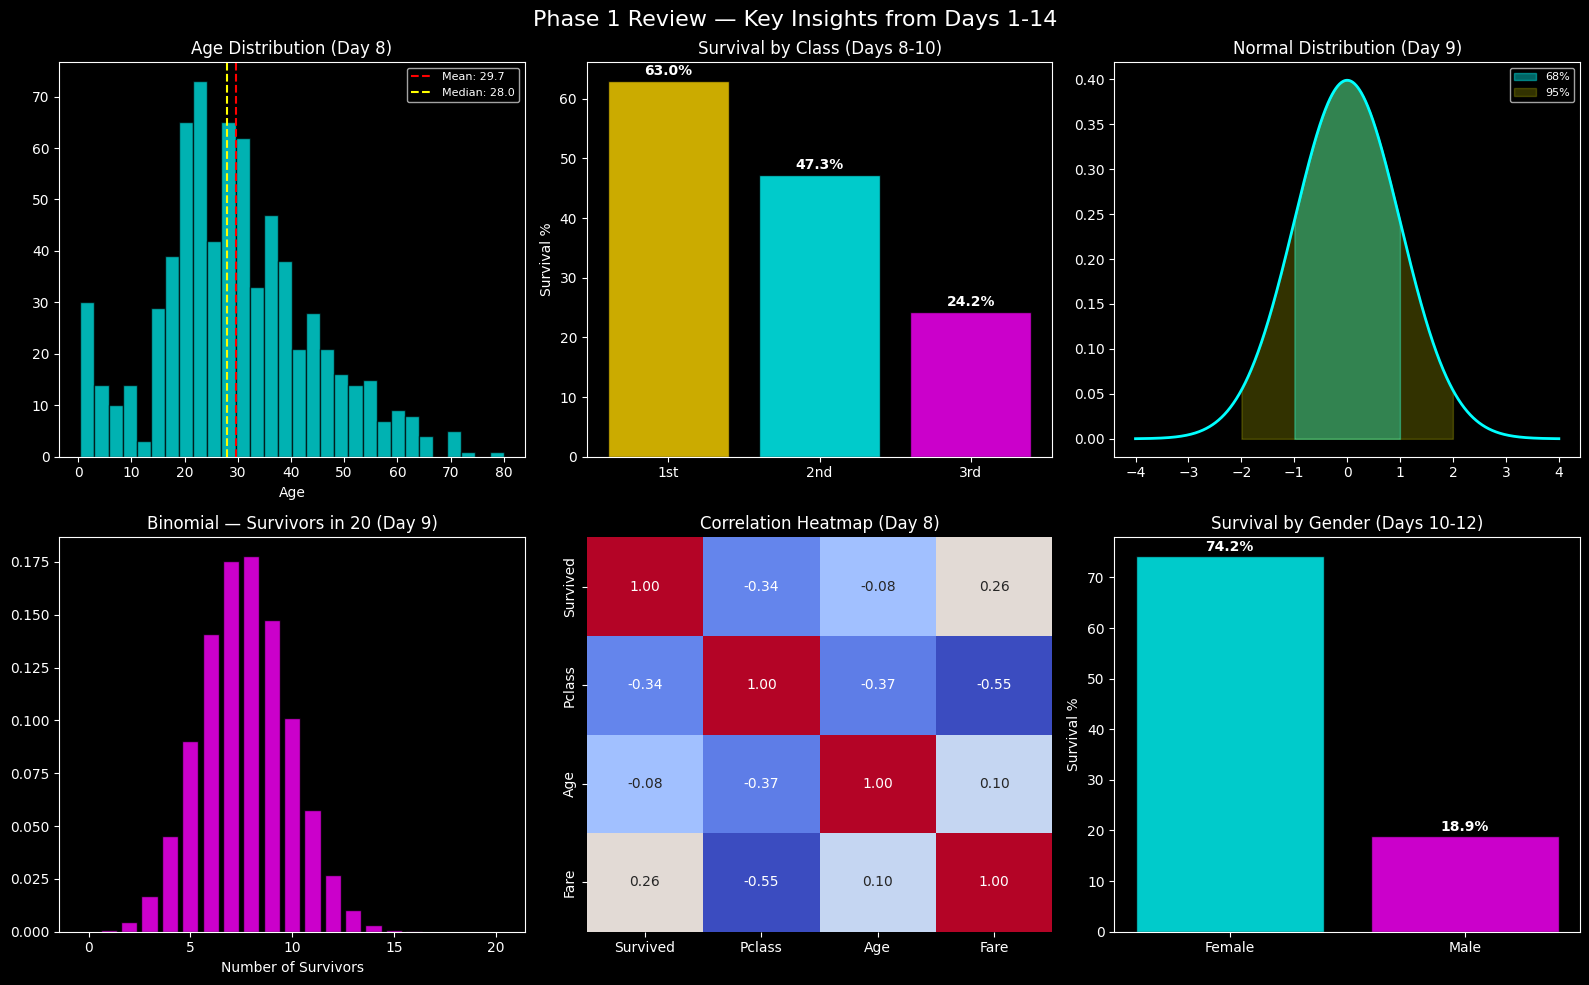

Phase 1 Visual Summary Complete! ✅


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Phase 1 Review — Key Insights from Days 1-14", fontsize=16)

# 1 — Age distribution
axes[0, 0].hist(df["Age"].dropna(), bins=30, color="cyan", alpha=0.7, edgecolor="black")
axes[0, 0].axvline(
    df["Age"].mean(), color="red", linestyle="--", label=f'Mean: {df["Age"].mean():.1f}'
)
axes[0, 0].axvline(
    df["Age"].median(),
    color="yellow",
    linestyle="--",
    label=f'Median: {df["Age"].median():.1f}',
)
axes[0, 0].set_title("Age Distribution (Day 8)")
axes[0, 0].set_xlabel("Age")
axes[0, 0].legend(fontsize=8)

# 2 — Survival by class
classes = [1, 2, 3]
survival_rates = [df[df["Pclass"] == c]["Survived"].mean() * 100 for c in classes]
axes[0, 1].bar(
    ["1st", "2nd", "3rd"],
    survival_rates,
    color=["gold", "cyan", "magenta"],
    edgecolor="black",
    alpha=0.8,
)
axes[0, 1].set_title("Survival by Class (Days 8-10)")
axes[0, 1].set_ylabel("Survival %")
for i, v in enumerate(survival_rates):
    axes[0, 1].text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")

# 3 — Normal distribution
x = np.linspace(-4, 4, 1000)
axes[0, 2].plot(x, stats.norm.pdf(x), color="cyan", linewidth=2)
axes[0, 2].fill_between(
    x,
    stats.norm.pdf(x),
    where=(x >= -1) & (x <= 1),
    alpha=0.4,
    color="cyan",
    label="68%",
)
axes[0, 2].fill_between(
    x,
    stats.norm.pdf(x),
    where=(x >= -2) & (x <= 2),
    alpha=0.2,
    color="yellow",
    label="95%",
)
axes[0, 2].set_title("Normal Distribution (Day 9)")
axes[0, 2].legend(fontsize=8)

# 4 — Binomial distribution
n, p = 20, 0.384
x2 = np.arange(0, 21)
axes[1, 0].bar(
    x2, stats.binom.pmf(x2, n, p), color="magenta", edgecolor="black", alpha=0.8
)
axes[1, 0].set_title("Binomial — Survivors in 20 (Day 9)")
axes[1, 0].set_xlabel("Number of Survivors")

# 5 — Correlation heatmap
cols = ["Survived", "Pclass", "Age", "Fare"]
corr = df[cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1, 1], cbar=False)
axes[1, 1].set_title("Correlation Heatmap (Day 8)")

# 6 — Survival by gender
genders = ["Female", "Male"]
rates = [
    df[df["Sex"] == "female"]["Survived"].mean() * 100,
    df[df["Sex"] == "male"]["Survived"].mean() * 100,
]
axes[1, 2].bar(genders, rates, color=["cyan", "magenta"], edgecolor="black", alpha=0.8)
axes[1, 2].set_title("Survival by Gender (Days 10-12)")
axes[1, 2].set_ylabel("Survival %")
for i, v in enumerate(rates):
    axes[1, 2].text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()
print("Phase 1 Visual Summary Complete! ✅")

## 5. Phase 1 Knowledge Check

In [ ]:
print("=" * 55)
print("       PHASE 1 KNOWLEDGE CHECK")
print("=" * 55)
print(
    """
STATISTICS (Days 8-11):
  ✅ Mean vs Median — median better for skewed data
  ✅ Skewness — Age: 0.39 (mild), Fare: 4.78 (extreme)
  ✅ Normal distribution — 68-95-99.7 rule
  ✅ Binomial — count successes in N trials
  ✅ Poisson — count rare events (λ = average rate)
  ✅ Conditional probability — P(A|B)
  ✅ Bayes theorem — P(A|B) = P(B|A)*P(A)/P(B)
  ✅ One-sample t-test — sample mean vs known value
  ✅ Two-sample t-test — compare two group means
  ✅ Chi-square — two categorical variables
  ✅ p-value — probability result happened by chance
  ✅ Confidence intervals — range of plausible values
  ✅ A/B testing — control vs treatment experiment
  ✅ Type I error — false positive (alpha)
  ✅ Type II error — false negative (beta)
  ✅ Statistical power — 1 - beta (want >= 80%)
  ✅ Sample size calculation — before running any test

SQL (Days 12-14):
  ✅ SELECT, WHERE, ORDER BY, LIMIT
  ✅ GROUP BY + aggregate functions
  ✅ HAVING — filter groups after aggregation
  ✅ INNER JOIN, LEFT JOIN, RIGHT JOIN
  ✅ Subqueries — WHERE, FROM, IN
  ✅ CASE WHEN — SQL if/elif/else
  ✅ ROW_NUMBER, RANK, DENSE_RANK
  ✅ LAG, LEAD — previous/next row values
  ✅ Running totals — SUM OVER with ROWS BETWEEN
  ✅ NTILE — divide into buckets
  ✅ CTEs — WITH name AS (...)
  ✅ Cohort analysis — DATE_TRUNC + GROUP BY cohort
  ✅ Funnel analysis — COUNT DISTINCT per stage
  ✅ Retention — DATEDIFF between orders
  ✅ Date arithmetic — DATE_TRUNC, DATEDIFF, DAYNAME
"""
)

print("=" * 55)
print("  PHASE 1 COMPLETE — 15/75 DAYS DONE! 🎉")
print("=" * 55)
print(f"\n  Days completed: 15")
print(f"  Days remaining: 60")
print(f"  Progress: {15/75*100:.0f}% complete")
print(f"\n  Next: Phase 2 — Core Machine Learning!")
print(f"  Starting Day 16: Scikit-learn & ML Workflow")

       PHASE 1 KNOWLEDGE CHECK

STATISTICS (Days 8-11):
  ✅ Mean vs Median — median better for skewed data
  ✅ Skewness — Age: 0.39 (mild), Fare: 4.78 (extreme)
  ✅ Normal distribution — 68-95-99.7 rule
  ✅ Binomial — count successes in N trials
  ✅ Poisson — count rare events (λ = average rate)
  ✅ Conditional probability — P(A|B)
  ✅ Bayes theorem — P(A|B) = P(B|A)*P(A)/P(B)
  ✅ One-sample t-test — sample mean vs known value
  ✅ Two-sample t-test — compare two group means
  ✅ Chi-square — two categorical variables
  ✅ p-value — probability result happened by chance
  ✅ Confidence intervals — range of plausible values
  ✅ A/B testing — control vs treatment experiment
  ✅ Type I error — false positive (alpha)
  ✅ Type II error — false negative (beta)
  ✅ Statistical power — 1 - beta (want >= 80%)
  ✅ Sample size calculation — before running any test

SQL (Days 12-14):
  ✅ SELECT, WHERE, ORDER BY, LIMIT
  ✅ GROUP BY + aggregate functions
  ✅ HAVING — filter groups after aggregation
  ✅ 

## 6. Phase 1 Complete — Key Takeaways 🎯

### What We Built in Phase 1 (Days 1-15)

#### Week 1 (Days 1-7) — Python & Data Tools
- NumPy arrays, vectorisation, broadcasting
- Pandas DataFrames, groupby, merging
- Polars — 14.9x faster than Pandas on 1M rows
- Matplotlib & Seaborn — 7 chart types
- Plotly interactive charts + Streamlit app
- DuckDB — SQL on DataFrames

#### Week 2 (Days 8-14) — Statistics & SQL
- Descriptive stats, distributions, visualisation
- Probability, Bayes theorem, 3 distributions
- Hypothesis testing — t-tests, chi-square
- A/B testing, confidence intervals, sample size
- SQL fundamentals — SELECT, WHERE, JOINs
- Advanced SQL — window functions, CTEs
- SQL for DS — cohort, funnel, retention analysis

### Phase 1 Stats
- 15 notebooks completed ✅
- 15 revision documents created ✅
- 15 GitHub commits pushed ✅
- 20% of 75-day journey complete ✅

### Biggest Insights from the Titanic Dataset
- Only 38.4% survived — less than 4 in 10
- Female + 1st class: 96.8% survived
- Male + 3rd class: only 13.5% survived
- Fare was overwhelmingly significant (p≈0.000)
- Gender was strongest survival predictor

### What's Coming — Phase 2 (Days 16-35)
- Day 16: Scikit-learn ML workflow
- Day 17: Linear Regression from scratch
- Day 18: Logistic Regression + metrics
- Day 19: Decision Trees
- Day 20: Random Forest
- Day 21: XGBoost & LightGBM
- Day 22: Feature Engineering
- Days 30-35: Project 1 — Deployed ML App!